**Прогнозирование уровня удовлетворённости работой и увольнения сотрудников**

**Описание проекта**

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам помогает машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании: отдел, грейд, количество лет в компании и другие. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетвоён.

Проект включает две задачи:

1) Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика, удовлетворённость работой напрямую влияет на отток сотрудников

2) Построить модель, которая сможет предсказать, какие сотрудники уволятся.

Будем выполнять задачи последовательно.



**Загрузим все необходимые библиотеки**

In [288]:
# Установка библиотек
!pip install phik
!pip install catboost

!pip install --upgrade scikit-learn

In [289]:
# Импорт библиотек
# Общие
import numpy as np
import pandas as pd

# Для графиков
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# Для создания pipeline и кодировки
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

# Модели
# Задача 1
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

# Задача 2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Метрики
from sklearn.metrics import make_scorer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

**ЗАДАЧА 1. Определение уровня удовлетворенности сотрудника**

План выполнения Задачи 1
- Загрузим датасеты
- Осуществим первоначальное исследование датасетов и предобработку данных: определим наличие пропусков, исследуем типы данных, возможные разночтения в написании значений признаков, проверим на дубли,
создадим небольшой pipeline для заполнения пропусков и заполним их
- Проведем исследовательский анализ данных
- Напишем pipeline для подготовки данных и выполним его: используем кодировщики не-числовых признаков и инструмент масштабирования для числовых
- Выберем несколько алгоритмов для предсказания уровня удовлетворенности работой, оценим наиболее подходящие алгоритмы при помощи метрики smape, функцию для расчета которой напишем
- Побдерем гимперпараметры наиболее удачного алгоритма при помощи GridSearch и используем его для предсказания показателя удовлетворенности работой
- Сделаем выводы

**Шаг 1. Загрузка данных.**

Мы получаем три датасета от компании-заказчика.

Датасет train_job_satisfaction_rate содержит данные тренировочной выборки, он включает и признаки, и целевое значение - уровень удовлетворенности сотрудников.

Датасет test_features содержит данные тестовой выборки, он включает признаки, которыми характеризуются сотрудники

Датасет test_job_satisfaction_rate содержит значения целевого показателя для тестовой выборки

Загружаем датасеты

In [ ]:
# Загрузим датафреймы
try:
    train = pd.read_csv("datasets/train_job_satisfaction_rate.csv")
    X_test = pd.read_csv("datasets/test_features.csv")
    y_test = pd.read_csv("datasets/test_target_job_satisfaction_rate.csv")
except FileNotFoundError:
    train = pd.read_csv("https://code.s3.yandex.net/datasets/train_job_satisfaction_rate.csv")
    X_test = pd.read_csv("https://code.s3.yandex.net/datasets/test_features.csv")
    y_test = pd.read_csv("https://code.s3.yandex.net/datasets/test_target_job_satisfaction_rate.csv")

Столбцы в датасетах:

id — уникальный идентификатор сотрудника;

dept — отдел, в котором работает сотрудник;

level — уровень занимаемой должности;

workload — уровень загруженности сотрудника;

employment_years — длительность работы в компании (в годах);

last_year_promo — показывает, было ли повышение за последний год;

last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;

supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;

salary — ежемесячная зарплата сотрудника;

job_satisfaction_rate — уровень удовлетворённости сотрудника
работой в компании, целевой признак.

**Шаг 2. Предобработка данных.**

Исследуем датасеты:

- визуально,

- получим информацию о них методом info(),

- изучим явные пропуски,

-  проверим на наличие неявных пропусков и разночтений в написании слов,

- проверим на наличие дублей,

- создадим pipeline для заполнения пропусков


**jsr_train**

In [291]:
# Проверка на пропуски, отображение типов данных
display(jsr_train.head())
display(jsr_train.shape)
display(jsr_train.info())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


(4000, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

В датасете jsr_train, имеющем 4000 строк и 10 столбцов, есть небольшое число явных пропусков в двух столбцах: "dept", "level", обработаем их в пайплайне позже, типы данных в порядке.

Проверим столбцы с не-численными признаками на наличие неявных пропусков и разночтений в написании слов

In [292]:
# Проверка уникальных значений в каждом не-числовом столбце
non_numeric_cols = ["dept", "level", "workload", "last_year_promo", "last_year_violations"]

for col in non_numeric_cols:
    unique_values = jsr_train[col].unique()
    print(f"Уникальные значения в столбце '{col}':")
    print(unique_values)
    print(f"Количество уникальных значений: {len(unique_values)}\n")

Уникальные значения в столбце 'dept':
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
Количество уникальных значений: 6

Уникальные значения в столбце 'level':
['junior' 'middle' 'sinior' nan]
Количество уникальных значений: 4

Уникальные значения в столбце 'workload':
['medium' 'high' 'low']
Количество уникальных значений: 3

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2



Неявные пропусков и проблемы с разночтением отсутствуют, но есть неправильно написанная должность "senior", исправим ее на всякий случай

In [293]:
# Заменим все вхождения "sinior" на "senior" в столбце "level"
jsr_train['level'] = jsr_train['level'].replace('sinior', 'senior')

# Проверим, что замена прошла успешно
jsr_train['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

Проверим на наличие дубликатов

In [294]:
# Всего дубликатов
jsr_train.duplicated().sum()

0

**jsr_X_test**

In [295]:
# Проверка на пропуски, отображение типов данных
display(jsr_X_test.head())
display(jsr_X_test.shape)
display(jsr_X_test.info())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


(2000, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

В датасете jsr_X_test, имеющем 2000 строк и 9 столбцов, есть несколько явных пропусков в столбцах "debt" и "level", типы данных в порядке

Проверим столбцы с не-численными признаками на наличие неявных пропусков и разночтений в написании слов

In [296]:
# Проверка уникальных значений в каждом не-числовом столбце
non_numeric_cols = ["dept", "level", "workload", "last_year_promo", "last_year_violations"]

for col in non_numeric_cols:
    unique_values = jsr_X_test[col].unique()
    print(f"Уникальные значения в столбце '{col}':")
    print(unique_values)
    print(f"Количество уникальных значений: {len(unique_values)}\n")

Уникальные значения в столбце 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
Количество уникальных значений: 7

Уникальные значения в столбце 'level':
['junior' 'middle' 'sinior' nan]
Количество уникальных значений: 4

Уникальные значения в столбце 'workload':
['medium' 'low' 'high' ' ']
Количество уникальных значений: 4

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2



Мы видим неявные пропуски в столбцах "debt" и "workload", также ошибочное написание "sinior"

In [297]:
# Заменим все вхождения "sinior" на "senior" в столбце "level"
jsr_X_test['level'] = jsr_X_test['level'].replace('sinior', 'senior')

# Проверим, что замена прошла успешно
jsr_X_test['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

Проверим на дубликаты

In [298]:
jsr_X_test.duplicated().sum()

0

**jsr_y_test**

In [299]:
# Проверка на пропуски, отображение типов данных
display(jsr_y_test.head())
display(jsr_y_test.shape)
display(jsr_y_test.info())

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


(2000, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


None

Мы видим, что датасет jsr_y_test имеет 2000 строк и 1 столбец, в нем нет неявных пропусков, типы данных в порядке.

In [300]:
# Проверим на наличие дубликаты
jsr_y_test.duplicated().sum()

0

**Напишем pipeline для заполнения явных и неявных пропусков**

Напишем pipeline, который будет обрабатывать пропуски, в нашем случае они находятся в не-числовых столбцах,
мы будем заполнять пропуски наиболее часто встречающимся значением

In [301]:
non_numeric_cols = ["dept", "level", "workload", "last_year_promo", "last_year_violations"]

# Создаём небольщой pipeline для обработки не-числовых столбцов
non_numeric_imputer = Pipeline(steps=[
    ('nan_filler_with_mode', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

# Создаем pipeline побольше для обработки не-чиловых столбцов (и не-обработки числовых)
SimpleFiller = ColumnTransformer(transformers=[
    ('non_numeric_filler', non_numeric_imputer, non_numeric_cols)],
    # Оставляем остальные столбцы без изменений
    remainder='passthrough',
    # Сохраним первоначальные имена
    verbose_feature_names_out=False)

Когда мы будем писать pipeline полностью, с кодировщиками, мы его дополним и видоизменим, не-числовые столбцы будут обрабатываться по-разному, в зависимости от того, категориальные ли это или порядковые признаки.

Напишем функцию для обработки датасетов jsr_train и jsr_X_test, будем иметь в виду, что у нас есть неявные пропуски - пробелы - и что после обработки pipeline значения вернутся как массив numpy, поэтому также сохраним имена столбцов и типы данных.

In [302]:
# Функция для замены пробелов на np.nan
def replace_spaces(X):
    return X.replace(' ', np.nan)

# Напишем функцию для обработки нескольких датасетов
datasets = [jsr_train, jsr_X_test]


def fill_spaces_and_nans(datasets, target):

    counter = 0
    cleaned_datasets = []

    for dataset in datasets:

        # Словарь с исходными типами данных
        original_dtypes = dataset.dtypes

        dataset = replace_spaces(dataset)

        if counter == 0:
            target_data = dataset[target]
            dataset = dataset.drop([target], axis = 1)
            dataset = SimpleFiller.fit_transform(dataset)
        else:
            dataset = SimpleFiller.transform(dataset)

        # Получаем первоначальные имена столбцов
        feature_names = SimpleFiller.get_feature_names_out()

        # Преобразуем массив numpy в датасет с первоначальными именами
        dataset = pd.DataFrame(dataset, columns = feature_names)

        if counter == 0:
            dataset = pd.concat([dataset, target_data], axis = 1)

        # Восстанавливаем исходные типы данных
        dataset = dataset.astype(original_dtypes.to_dict())

        cleaned_datasets.append(dataset)

        counter += 1

    return cleaned_datasets

# Применим функцию с pipeline
cleaned_datasets = fill_spaces_and_nans(datasets, "job_satisfaction_rate")

# Проверим результат обработки
for dataset in cleaned_datasets:
    display(dataset.info())
    for col in non_numeric_cols:
        unique_values = dataset[col].unique()
        print(f"Уникальные значения в столбце '{col}':")
        print(unique_values)
        print(f"Количество уникальных значений: {len(unique_values)}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   4000 non-null   object 
 1   level                  4000 non-null   object 
 2   workload               4000 non-null   object 
 3   last_year_promo        4000 non-null   object 
 4   last_year_violations   4000 non-null   object 
 5   id                     4000 non-null   int64  
 6   employment_years       4000 non-null   int64  
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

Уникальные значения в столбце 'dept':
['sales' 'hr' 'technology' 'purchasing' 'marketing']
Количество уникальных значений: 5

Уникальные значения в столбце 'level':
['junior' 'middle' 'senior']
Количество уникальных значений: 3

Уникальные значения в столбце 'workload':
['medium' 'high' 'low']
Количество уникальных значений: 3

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   2000 non-null   object
 1   level                  2000 non-null   object
 2   workload               2000 non-null   object
 3   last_year_promo        2000 non-null   object
 4   last_year_violations   2000 non-null   object
 5   id 

None

Уникальные значения в столбце 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology']
Количество уникальных значений: 5

Уникальные значения в столбце 'level':
['junior' 'middle' 'senior']
Количество уникальных значений: 3

Уникальные значения в столбце 'workload':
['medium' 'low' 'high']
Количество уникальных значений: 3

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2



In [303]:
# Заменим первоначальные датасеты датасетами с заполненными пропусками (методом распаковки)
jsr_train, jsr_X_test = cleaned_datasets

display(jsr_train.info())
display(jsr_X_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   4000 non-null   object 
 1   level                  4000 non-null   object 
 2   workload               4000 non-null   object 
 3   last_year_promo        4000 non-null   object 
 4   last_year_violations   4000 non-null   object 
 5   id                     4000 non-null   int64  
 6   employment_years       4000 non-null   int64  
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   2000 non-null   object
 1   level                  2000 non-null   object
 2   workload               2000 non-null   object
 3   last_year_promo        2000 non-null   object
 4   last_year_violations   2000 non-null   object
 5   id                     2000 non-null   int64 
 6   employment_years       2000 non-null   int64 
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

**Выводы**:
Были проведены исследования трех датасетов jsr_train, jsr_X_test и jsr_y_test:

- тренировочная выборка представлена датасетом jsr_train, содержит 4000 строк и 10 столбцов, тестовая выборка - 2000 строк, которые находятся в двух датасетах: признаки в jsr_X_test, который имеет 9 столбцов, и target - уровень удовлетворенности сотрудников - в датасете jsr_y_test, имеющем 2 столбца;

- в датасетах jsr_train и jsr_X_test была исправлена ошибка в должности "senior" в столбце "level";

- типы данных проверены и не нуждаются в изменении;

- дублей не обнаружено;

- были обнаружены явные и неявные пропуски в датасетах jsr_X_test и jsr_train, они были заполнены при помощи пайплайна SimpleFiller, который впоследствии будет дополнен;

- выбросы не исследовались, они будут исследоваться далее.

**Шаг 3. Исследовательский анализ данных.**

Проведем исследовательский анализ данных для датасетов jsr_train и jsr_X_test:
- Статистические показатели: посмотрим на явные аномальные значения
- Исследуем непрерывные числовые признаки: используем гистограммы и ящики с усами
- Исследуем дискретные числовые признаки: используем гистограммы вида countplot
- Исследуем категориальные и порядковые признаки при помощи круговых диаграмм
- Исследуем уровень удовлетворенности в зависимости от категориальных и порядковых признаков
- Используем барплоты, чтобы увидеть, как различается уровень удовлетворенности в зависимости от бинарных признаков
- Построим матрицу корреляции


Исследуем статистические показатели датасетов при помощи метода describe()

In [304]:
jsr_train.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


In [305]:
jsr_X_test.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [306]:
jsr_y_test.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


Аномальные значения в датасетах не выявлены

**Построим гистограммы распределения значения с кривой плотности распределения и ящики с усами для непрерывных числовых признаков**

In [307]:
# Функция для построения гистограммы и ящика с усами
def histogram_and_boxplot(df, columns):

    for column in columns:
        plt.figure(figsize=(10, 4))

        # Гистограмма и кривая плотности
        plt.subplot(1, 2, 1)
        sns.histplot(df[column], kde=True, color='blue', bins=20)
        plt.title(f'Гистограмма и плотность: {column}', fontsize=10)
        plt.xlabel(column, fontsize=8)
        plt.ylabel('Частота', fontsize=8)

        # Ящики с усами
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[column], color='lightgreen')
        plt.title(f'Ящики с усами: {column}', fontsize=10)
        plt.xlabel(column, fontsize=8)

        # Уточнение пропорций и отступов
        plt.tight_layout(pad=2.0)
        plt.show()

Применим функцию к исследуемым датасетам

In [308]:
# Определим числовые признаки
numeric_cols_train = ["salary", "job_satisfaction_rate"]

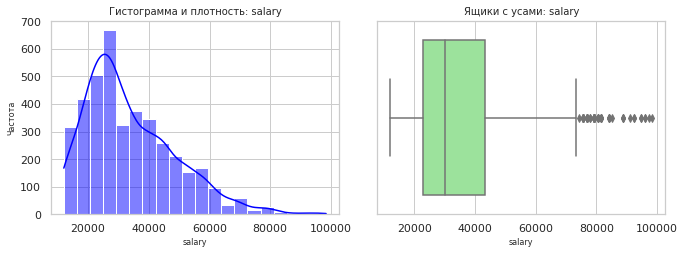

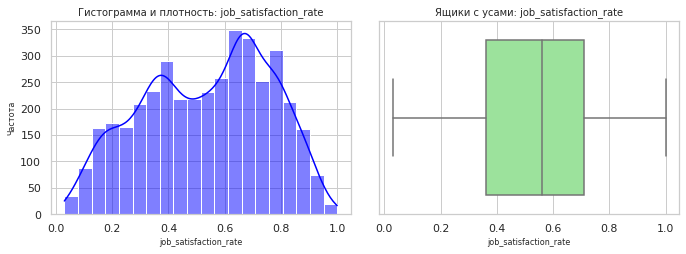

In [309]:
histogram_and_boxplot(jsr_train, numeric_cols_train)

Изучив гистограммы и ящики с усами, мы видим, что:

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 25-30.

- половина сотрудников оценивает удовлетворенность работой на 35 - 70%, медиана проходит на уровне чуть меньше 60%.

**Гистограммы вида countplot для дискретных числовых признаков**

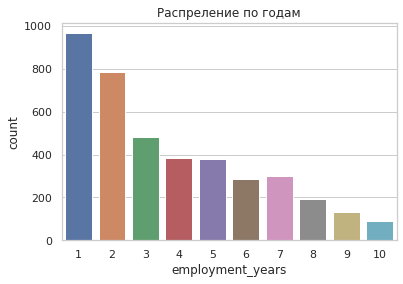

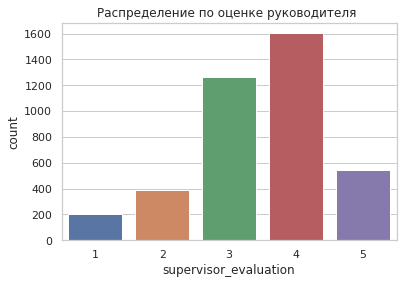

In [310]:
# Для признака employment_years
sns.countplot(data=jsr_train, x='employment_years')
plt.title('Распреление по годам')
plt.show()

# Для признака supervisor_evaluation
sns.countplot(data=jsr_train, x='supervisor_evaluation')
plt.title('Распределение по оценке руководителя ')
plt.show()

Изучив гистограммы вида countplot мы видим:

- Большая часть сотрудников не долго работает в компании, самая многочисленная группа - работающие около 1 года, также многочисленными являются группы сотрудников, работающих 2 и 3 года в компании, самая малочисленная группа - сотрудники, которые уже 10 лет не меняли работу.

- Самая частая оценка сотрудника руководителем "4", достаточно многочисленна и группа сотрудников, имеющих оценку "3", меньше всего сотрудников с оценкой "1".

**Создадим также круговые диаграммы для категориальных и порядковых признаков**

In [311]:
categorical_ordinal_cols = ["dept", "level", "workload"]

def draw_pie_diagram(df, columns):
    for column in columns:
        # Создаем новую фигуру с размером 5x5
        plt.figure(figsize=(5, 5))

        # Считаем количество уникальных значений для каждой категории
        value_counts = df[column].value_counts()

        # Строим круговую диаграмму
        plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=45, colors=plt.cm.Paired.colors)
        plt.title(f'Круговая диаграмма для {column}')

        # Показываем диаграмму
        plt.show()

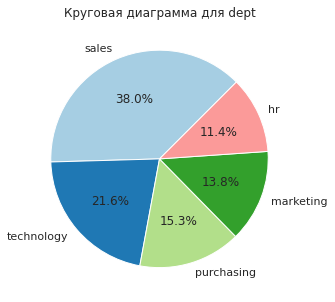

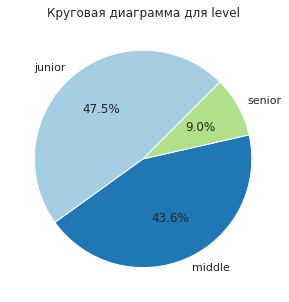

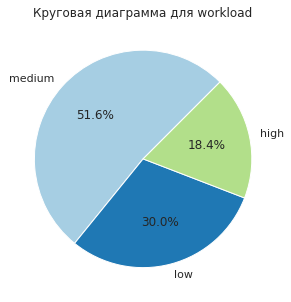

In [312]:
draw_pie_diagram(jsr_train, categorical_ordinal_cols)

Изучив круговые диаграммы, мы можем сказать, что:

- больше всего сотрудников работает в отделах sales - 38% и в technology - 21,6%,

- в других отделах: purchasing - 15.3%, marketing - 13.8%, hr - 11.4%;

- значительное большинство сотрудников имеют грейд junior или middle - 47.5 % и 43.6%, лишь оставшиеся около 9% - senior.

- уровень загруженности большинства сотрудников средний, их 51.6%, сотрудников с высоким уровнем загруженности 18.4 % и 30% с низким уровнем загруженности.

**Создадим диаграммы размаха для категориальных и порядковых признаков**

Бинарные рассмотрим отдельно



In [313]:
non_numeric_cols = ["dept", "level", "workload"]

In [314]:
def plot_boxplot(data, x_column, y_column="job_satisfaction_rate", title=None, figsize=(10, 6)):

    plt.figure(figsize=figsize)
    sns.boxplot(x=x_column, y=y_column, data=data)

    # Установка заголовка
    if title is None:
        title = f"Распределение {y_column} в зависимости от {x_column}"

    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

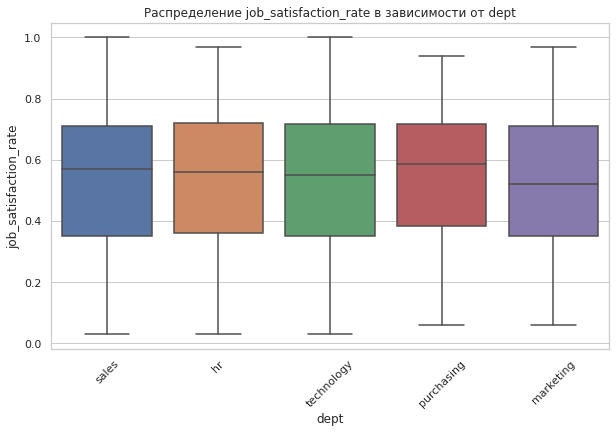

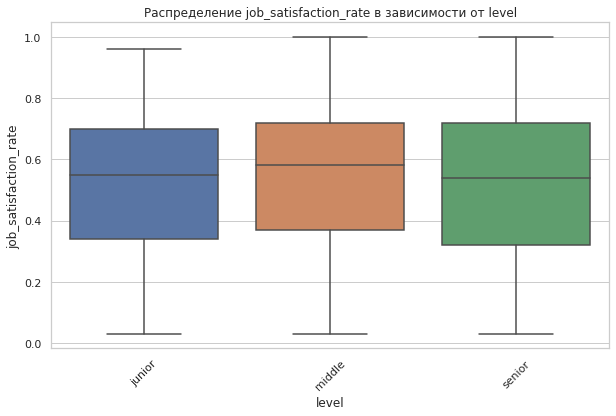

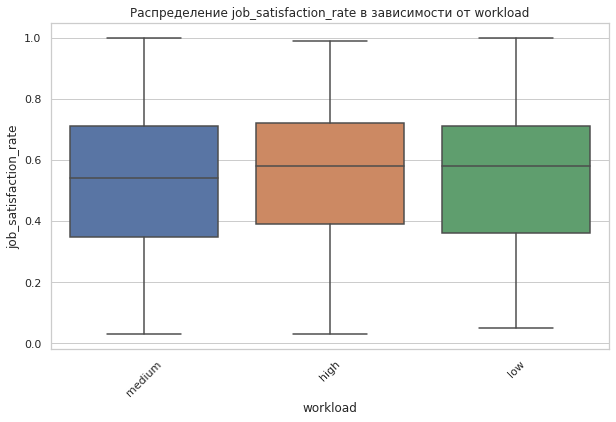

In [315]:
for column in non_numeric_cols:
  plot_boxplot(jsr_train, column)

Мы видим, что уровень удовлетворенности в среднем не сильно различается у сотрудников различных отделов, а также не сильно изменяется в зависимости от загруженности и грейда.

**Диаграммы для бинарных признаков**

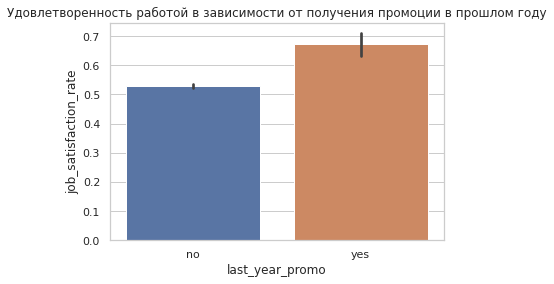

In [316]:
plt.figure(figsize=(6, 4))
sns.barplot(x="last_year_promo", y="job_satisfaction_rate", data=jsr_train)
plt.title("Удовлетворенность работой в зависимости от получения промоции в прошлом году")
plt.show()

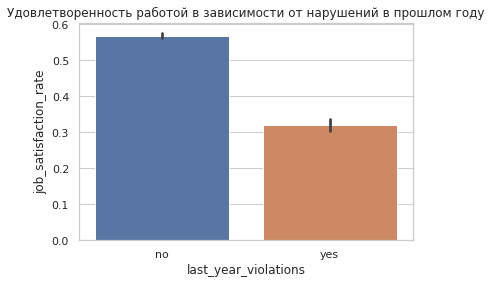

In [317]:
plt.figure(figsize=(6, 4))
sns.barplot(x="last_year_violations", y="job_satisfaction_rate", data=jsr_train)
plt.title("Удовлетворенность работой в зависимости от нарушений в прошлом году")
plt.show()

Мы видим, что уровень удовлетворенности сотрудников, которые получили повышение за последний год, несколько выше, чем у тех, кто не получил, они составляют 52% и 67%.

Еще больше заметно различие в уровне удовлетворенности тех, кто допускал нарушения договора и тех, кто не нарушал, они составляют 31% и 57%.

**Проведем корреляционный анализ** на датасете jsr_train

In [318]:
# Создаём список непрерывных числовых признаков
interval_cols = [
    'salary',
    'job_satisfaction_rate'
]

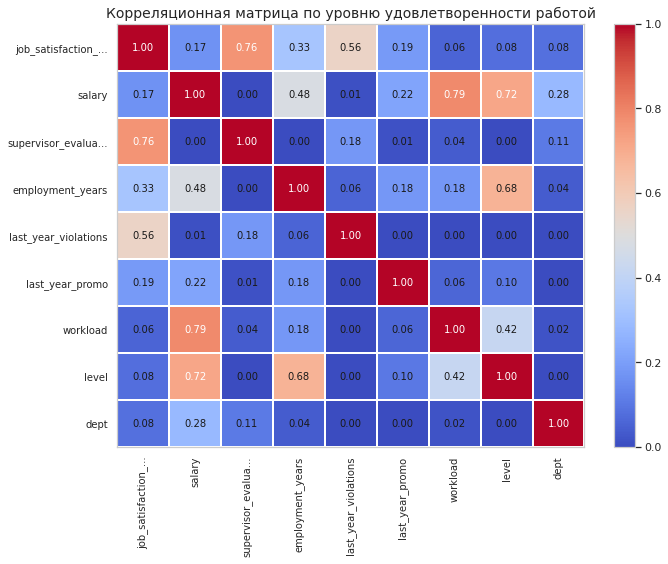

In [319]:
# Считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(jsr_train.drop('id', axis=1), interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'Корреляционная матрица по уровню удовлетворенности работой',
    fontsize_factor=1,
    figsize=(10, 8),
)

Удовлетворенность работой выраженно положительно коррелирует с оценкой руководителя,
также заметна корреляция с бинарным признаком нарушений, и, исходя из графиков выше, эта корреляция такова: есть нарушение - меньше удовлетворенность.

Проведем аналогичный анализ тестовой выборки.

In [320]:
# Соединим датасеты jsr_X_test и jsr_y_test
jsr_test = jsr_X_test.merge(jsr_y_test, on = "id", how = "inner")

# Проверим
jsr_test.shape

(2000, 10)

**Гистограммы и ящики с усами для числовых признаков**

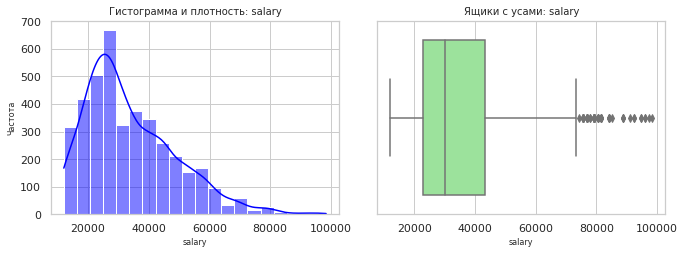

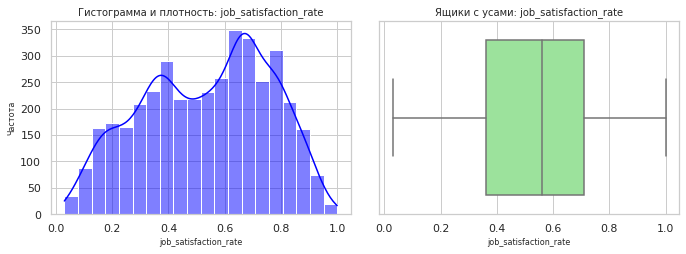

In [321]:
# Определим числовые признаки
numeric_cols_test = numeric_cols_train
histogram_and_boxplot(jsr_train, numeric_cols_train)

Изучив гистограммы и ящики с усами, мы видим, что:

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 25-30.

- половина сотрудников оценивает удовлетворенность работой на 35 - 70%, медиана проходит на уровне чуть меньше 60%.

Данные схожи с тренировочной выборкой.

**Гистограмма вида countplot для дискретных числовых признаков**

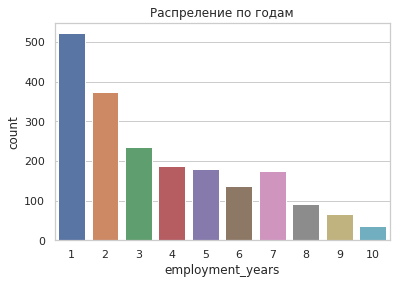

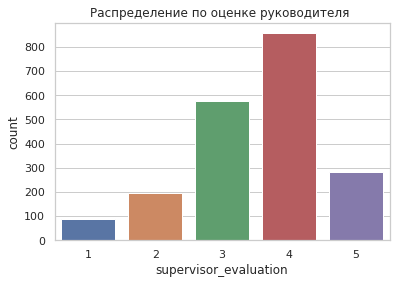

In [322]:
# Для признака employment_years
sns.countplot(data=jsr_test, x='employment_years')
plt.title('Распреление по годам')
plt.show()

# Для признака supervisor_evaluation
sns.countplot(data=jsr_test, x='supervisor_evaluation')
plt.title('Распределение по оценке руководителя ')
plt.show()

Данные также похожи с тренировочной выборкой - большинство сотрудников недолго работает в компании(1-2 года), самые часты оценки руководителя 4 и 3.

**Круговые диаграммы для категориальных признаков**

Бинарные будут рассмотрены ниже

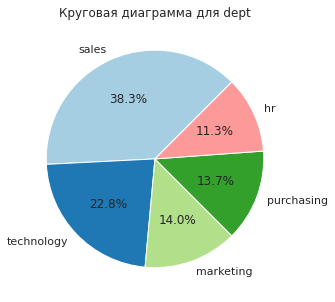

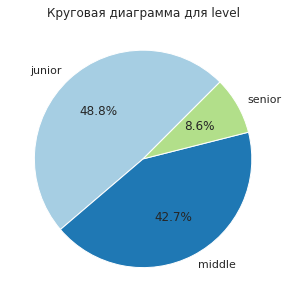

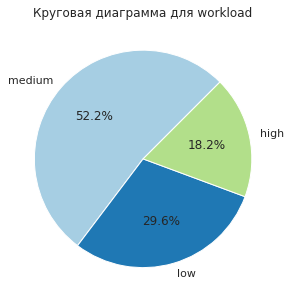

In [323]:
draw_pie_diagram(jsr_test, categorical_ordinal_cols)

Изучив диаграммы видим, что данные схожи с тренировочной выборкой. Больше всего сотрудников в sales и technology, большинство сотрудников junior и middle и чуть больше половины сотрудников имеют среднюю загруженность.

**Создадим диаграммы размаха для категориальных и порядковых признаков**

Бинарные рассмотрим отдельно


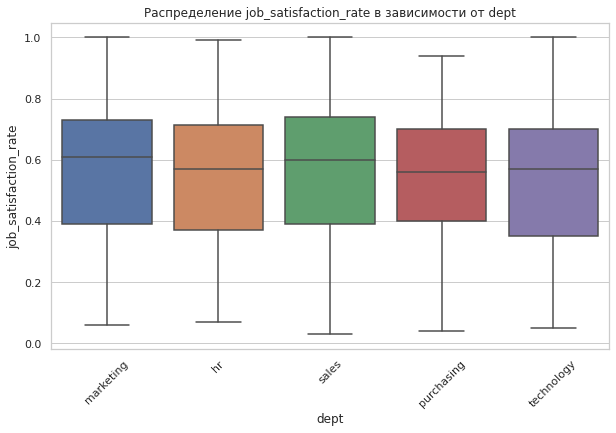

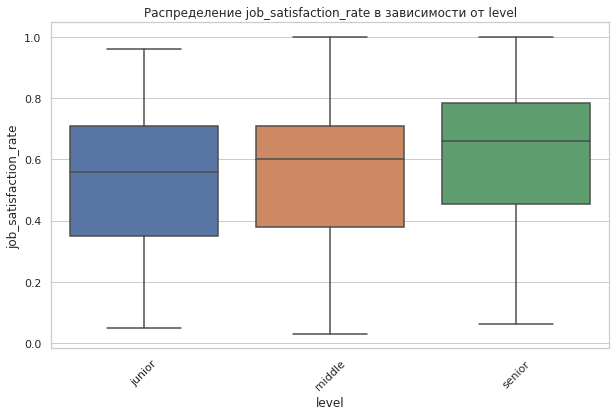

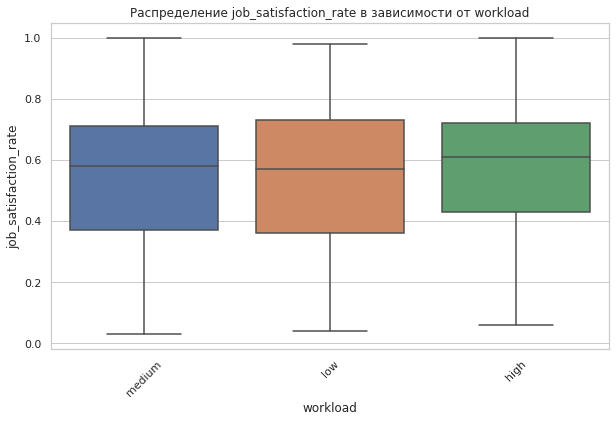

In [324]:
for column in non_numeric_cols:
  plot_boxplot(jsr_test, column)

В целом данные схожи с тренировочной выборкой. Здесь немного выше job_satisfaction_rate у senior.

**Диаграммы для бинарных признаков**

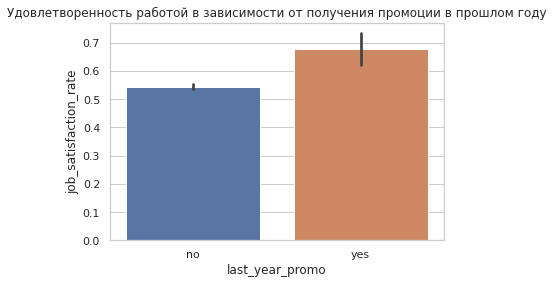

In [325]:
plt.figure(figsize=(6, 4))
sns.barplot(x="last_year_promo", y="job_satisfaction_rate", data=jsr_test)
plt.title("Удовлетворенность работой в зависимости от получения промоции в прошлом году")
plt.show()

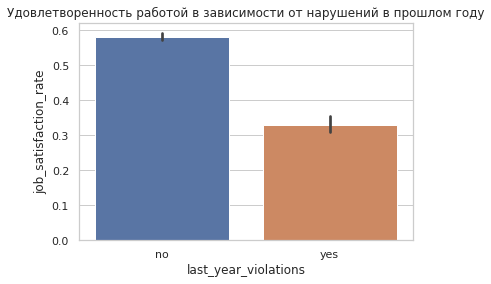

In [326]:
plt.figure(figsize=(6, 4))
sns.barplot(x="last_year_violations", y="job_satisfaction_rate", data=jsr_test)
plt.title("Удовлетворенность работой в зависимости от нарушений в прошлом году")
plt.show()

По бинарным признакам данные также схожи с тренировочной выборкой.

**Матрица корреляции для test**

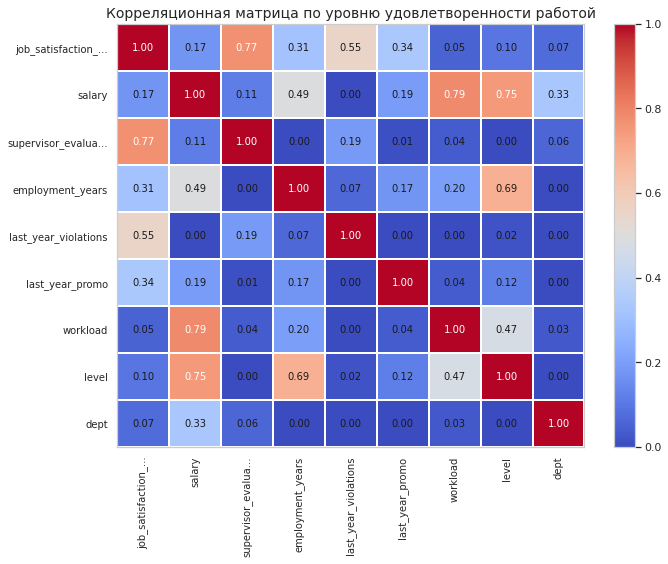

In [327]:
# Считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(jsr_test.drop('id', axis=1), interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'Корреляционная матрица по уровню удовлетворенности работой',
    fontsize_factor=1,
    figsize=(10, 8),
)

Матрица корреляции похожа с матрицей по тренировочной выборке. Здесь увеличилась корреляция с last_year_promo

**Выводы**

Мы провели исследовательский анализ данных.

1) Изучив непрерывные численные признаки jsr_train, мы видим, что:

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 25-30.

- половина сотрудников оценивает удовлетворенность работой на 35 - 70%, медиана проходит на уровне чуть меньше 60%.

2) Изучив дискретные численные признаки jsr_train, мы видим:

- Большая часть сотрудников не долго работает в компании, самая многочисленная группа - работающие около 1 года, также многочисленными являются группы сотрудников, работающих 2 и 3 года в компании, самая малочисленная группа - сотрудники, которые уже 10 лет не меняли работу.

- Самая частая оценка сотрудника руководителем "4", достаточно многочисленна и группа сотрудников, имеющих оценку "3", меньше всего сотрудников с оценкой "1".

3) Изучив категориальные признаки jsr_train, мы можем сказать, что:

- больше всего сотрудников работает в отделах sales - 38% и в technology - 21,6%,

- в других отделах: purchasing - 15.3%, marketing - 13.8%, hr - 11.4%;

- значительное большинство сотрудников имеют грейд junior или middle - 47.5 % и 43.6%, лишь оставшиеся около 9% - senior.

- уровень загруженности большинства сотрудников средний, их 51.6%, сотрудников с высоким уровнем загруженности 18.4 % и 30% с низким уровнем загруженности.

4) Изучив бинарные признаки jsr_train, мы пришли к выводу, что:

- уровень удовлетворенности сотрудников, которые получили повышение за последний год, несколько выше, чем у тех, кто не получил, они составляют 52% и 67%.

- еще больше заметно различие в уровне удовлетворенности тех, кто допускал нарушения договора и тех, кто не нарушал, они составляют 31% и 57%.

5) Построив матрицу корреляции jsr_train, мы замечаем, что:

- удовлетворенность работой выраженно положительно коррелирует с оценкой руководителя,

- также заметна корреляция с бинарным признаком нарушений, и, исходя из графиков выше, эта корреляция такова: есть нарушение - меньше удовлетворенность.

6) Провеля аналогичные исследования датасета jsr_test, мы убедились, что его данные имеют очень похожие цифры и закономерности, то есть можно будет использовать модель, обученную на jsr_train, и она должна быть адекватна.

**Шаг 4. Подготовка данных**

Создадим pipeline подготовки данных, который будет включать:

- заполнени пропусков: мы его уже сделали, но, тем не менее, добавим заполнение пропусков в общий pipeline

- масштабирование Standard Scaler для числовых признаков

- кодирование Ordinal Encoder для порядковых признаков

- кодирование One Hot Encoder для категориальных признаков



Pipeline предобработки признаков

In [328]:
# Опрделим числовые, порядковые и категориальные признаки
numeric_cols = ["employment_years", "supervisor_evaluation", "salary"]
categorical_cols = ["dept", "last_year_promo", "last_year_violations"]
ordinal_cols = ["level", "workload"]

In [329]:
# Pipeline для числовых признаков, в нашем случае нет пропусков, но для возможных пропусков используем заполнение медианой
numeric_pipe = Pipeline(steps=[
    ("SimpleImputer", SimpleImputer(missing_values = np.nan, strategy = "median")),
    ("StandardScaler", StandardScaler())]
)

# Pipeline для порядковых признаков
ordinal_pipe = Pipeline(steps=[
    ("SimpleImputer", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),
    ("OrdinalEncoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [330]:
# Pipeline для категориальных признаков
categorical_pipe = Pipeline(steps=[
    ("SimpleImputer", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),
    ("OneHotEncoder", OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore'))
])

In [331]:
# Единый pipeline preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("NumericPipe", numeric_pipe, numeric_cols),
    ("CategoricalPipe", categorical_pipe, categorical_cols),
    ("OrdinalPipe", ordinal_pipe, ordinal_cols)
], remainder = "passthrough", verbose_feature_names_out = False)

Осуществим обработку датасетов при помощи preprocessor пайплайна.

In [332]:
# удалим id
jsr_train = jsr_train.drop(["id"], axis = 1)
jsr_test = jsr_test.drop(["id"], axis = 1)

In [333]:
# удалим дубликаты в тренировочной выборке
jsr_train.duplicated().sum()
jsr_train = jsr_train.drop_duplicates()

In [334]:
# Разделим датасеты на признаки и целевые показатели
jsr_X_train = jsr_train.drop(["job_satisfaction_rate"], axis = 1)

In [335]:
jsr_y_train = jsr_train["job_satisfaction_rate"]
jsr_X_test = jsr_test.drop(["job_satisfaction_rate"], axis = 1)
jsr_y_test = jsr_test["job_satisfaction_rate"]

In [336]:
# Замена пробелов nan
jsr_X_train = replace_spaces(jsr_X_train)
jsr_X_test = replace_spaces(jsr_X_test)
# Обработка данных
jsr_X_train = preprocessor.fit_transform(jsr_X_train)
jsr_X_test = preprocessor.transform(jsr_X_test)

**Выводы**: на этапе обработки данных мы сделали следующие шаги.

- Соединили данные датасетов jsr_X_test и jsr_y_test по столбцу "id" - уникальному идентифиатору сотрудика, чтобы данные по каждому сотруднику были соединены корректно.

- Разделили признаки обоих датасетов на числовые, категориальные и порядковые.

- Написали пайплайн обработки признаков preprocessor, которые обрабатывает каждый из видов признаков:
  - не обрабатывает столбец "id"
  - заполняет пропуски и осуществляет масштабирование числовых признаков
  - заполняет пропуски и кодирует категориальные признаки OneHotEncoder-ом
  - заполняет пропуски и кодирует порядковые признаки OrdinalEncoder-ом
  
- Разделили тренировочную и тестовую выборки на признаки и целевые показатели.

- Заменили неявные пропуски на явные nan.

- Осуществили обработку данных пайплайном preprocessor.

**Шаг 5. Обучение моделей.**

План действий на этапе обучения моделей:

- определим метрику SMAPE

- выберем алгоритмы для применения: линейная регрессия,
дерево решений, случайный лес и алгоритм градиентного бустинга для деревьев решений Catboost, разработанный Яндексом

- подберем параметры для лучшей модели

- осуществим предсказание уровня удовлетворенности сотрудников лучше моделью

Метрика SMAPE - Symmetric Mean Absolute Percentage Error,
 симметричное среднее абсолютное процентное отклонение:

In [337]:
def SMAPE(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)

    # Избегаем деления на ноль
    denominator = (np.abs(actual) + np.abs(predicted)) / 2

    # Обрабатываем случай, когда actual и predicted равны нулю
    mask = denominator != 0

    # Вычисляем SMAPE только для ненулевых значений знаменателя
    smape = np.mean(np.abs(predicted[mask] - actual[mask]) / denominator[mask]) * 100

    return smape

RANDOM_STATE = 3
scorer = make_scorer(SMAPE, greater_is_better = False)

Проведем первоначальное тестирование алгоритмов,
выведем значение SMAPE для test, наша цель SMAPE меньше или равно 15.

Желаемой SMAPE удалось достичь при помощи алгоритмов Случайный лес RandomForesRegressor и градиетный бустинг на деревьях решений CatBoostRegressor, разработанный Яндексом.

Мы видим, что наилучший результат показывает CatoBoostRegressor при значении гиперпараметра максимальная глубина от 6 до 8.


Найдем более точные параметры для CatboostRegressor инструментом поиска по сетке параметров GridSearch:

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>
Исправил
</div>

In [338]:
# Создаем Pipeline и добавляем модели в сетку гиперпараметров
pipeline = Pipeline([
    ('model', LinearRegression())  # Место под модели, будет перебираться GridSearch
])

# Сетка гиперпараметров для всех моделей
param_grid = [
    # Параметры для LinearRegression (нет гиперпараметров)
    {
        'model': [LinearRegression()],
    },
    # Параметры для DecisionTreeRegressor
    {
        'model': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'model__max_depth': range(1, 21)
    },
    # Параметры для RandomForestRegressor
    {
        'model': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': range(5, 16, 2)
    },
    # Параметры для CatBoostRegressor
    {
        'model': [CatBoostRegressor(random_state=RANDOM_STATE, silent=True)],
        'model__iterations': [100, 130, 150],
        'model__depth': [6, 7, 8]
    }
]

# Настройка GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer,
    cv=3,
    verbose=1
)

# Обучение модели на тренировочной выборке
grid_search.fit(jsr_X_train, jsr_y_train)

# Выводим лучшие параметры и модель
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Лучшая модель: {best_params['model'].__class__.__name__}")
print(f"Лучшие параметры: {best_params}")
print(f"Лучший результат SMAPE на кросс-валидации: {abs(best_score)}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Лучшая модель: CatBoostRegressor
Лучшие параметры: {'model': <catboost.core.CatBoostRegressor object at 0x7f2990a10370>, 'model__depth': 7, 'model__iterations': 100}
Лучший результат SMAPE на кросс-валидации: 11.709227446749173


In [339]:
# Оценка лучшей модели на тестовой выборке
best_model = grid_search.best_estimator_
jsr_y_pred = best_model.predict(jsr_X_test)

# Вычисляем SMAPE на тестовой выборке
smape_test = SMAPE(jsr_y_test, jsr_y_pred)
print(f"SMAPE на тестовой выборке: {smape_test}")

SMAPE на тестовой выборке: 10.885694564838973


**Выводы**: на этапе обучения моделей мы

- написали функцию для оценки smape

- используя метрику smape сравнили алгоритмы:
    - линейной регрессии
    - Decision Tree Regressor
    - Random Forest Regressor
    - CatBoost Regressor

- желаемой мы считаем метрику smape менее 15 на тестовых данных, и такому результату соответствуют Random Forest Regressor и CatBoost Regressor, мы выбрали последний

- при помощи инструмента поиск по сетке параметров GridSearch и ручного подбора нам удалось достичь smape 10.85 на тестовых данных

- мы обучили модель CatBoostRegressor и сделали предсказание
уровня удовлетворенности сотрудников

**Шаг 6. Выводы**

Наша задача состояла в предсказании уровня удовлетворенности сотрудника на основе его характеристик: грейда, отдела, оценки руководителя, количества лет на текущей работе, зарплаты, загруженности, наличия/отсутствия повышения за год, нарушения/не-нарушения договора за год.

Мы провели предобработку данных. Мы не обнаружили неподходящих типов данных, дублей, но выявили явные и неявные пропуски и заполнили их при помощи специальной функции и небольшого pipeline SimpleImputer.

Затем мы провели исследовательский анализ данных.

1) Изучив непрерывные численные признаки jsr_train, мы видим, что:

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 25-30.

- половина сотрудников оценивает удовлетворенность работой на 35 - 70%, медиана проходит на уровне чуть меньше 60%.

2) Изучив дискретные численные признаки jsr_train, мы видим:

- Большая часть сотрудников не долго работает в компании, самая многочисленная группа - работающие около 1 года, также многочисленными являются группы сотрудников, работающих 2 и 3 года в компании, самая малочисленная группа - сотрудники, которые уже 10 лет не меняли работу.

- Самая частая оценка сотрудника руководителем "4", достаточно многочисленна и группа сотрудников, имеющих оценку "3", меньше всего сотрудников с оценкой "1".

3) Изучив категориальные признаки jsr_train, мы можем сказать, что:

- больше всего сотрудников работает в отделах sales - 38% и в technology - 21,6%,

- в других отделах: purchasing - 15.3%, marketing - 13.8%, hr - 11.4%;

- значительное большинство сотрудников имеют грейд junior или middle - 47.5 % и 43.6%, лишь оставшиеся около 9% - senior.

- уровень загруженности большинства сотрудников средний, их 51.6%, сотрудников с высоким уровнем загруженности 18.4 % и 30% с низким уровнем загруженности.

4) Изучив бинарные признаки jsr_train, мы пришли к выводу, что:

- уровень удовлетворенности сотрудников, которые получили повышение за последний год, несколько выше, чем у тех, кто не получил, они составляют 52% и 67%.

- еще больше заметно различие в уровне удовлетворенности тех, кто допускал нарушения договора и тех, кто не нарушал, они составляют 31% и 57%.

5) Построив матрицу корреляции jsr_train, мы замечаем, что:

- удовлетворенность работой выраженно положительно коррелирует с оценкой руководителя,

- также заметна корреляция с бинарным признаком нарушений, и, исходя из графиков выше, эта корреляция такова: есть нарушение - меньше удовлетворенность.

6) Провеля аналогичные исследования датасета jsr_test, мы убедились, что его данные имеют очень похожие цифры и закономерности, то есть можно будет использовать модель, обученную на jsr_train, и она должна быть адекватна.

Далее мы написали pipeline обработки данных preprocessor, который обрабатывает каждый из видов признаков:
  - не обрабатывает столбец "id" - идентификатор сотрудника
  - заполняет пропуски и осуществляет масштабирование числовых признаков Standard Scaler-ом
  - заполняет пропуски и кодирует категориальные признаки OneHotEncoder-ом
  - заполняет пропуски и кодирует порядковые признаки OrdinalEncoder-ом
  - предусмотрена кодировка энкодерами ранее невстречавшихся значений

Мы обработали пайплайном данные тренировочной и тестовой выборок и тестировали несколько алгоритмов для решения задачи предсказания уровня удовлетворения сотрудников работой, для оценки мы использовали метрику SMAPE - Symmetric Mean Absolute Percentage Error, симметричное среднее абсолютное процентное отклонение. Желательной оценкой алгоритма была SMAPE менее или равная 15.

Мы протестировали Linear Regression, Decision Tree Regressor, Random Forest Regressor и CatBoostRegressor при помощи инструмента GridSearch и кроссвалидации на тренирочоной выборке. Лучшим оказался CatBoostRegressor.

Далее мы сделали предсказание уровня удовлетворенности на тестовой выборке и получили SMAPE = 10.89, что является очень хорошим результатом.

Используя выбранную модель и подобранные параметры, мы предсказали уровень удовлетворенности сотрудников работой.



**ЗАДАЧА 2. Предсказание увольнения сотрудника**

План выполнения Задачи 2
- Загрузим датасеты
- Осуществим первоначальное исследование датасетов и предобработку данных: определим наличие пропусков, исследуем типы данных, возможные разночтения в написании значений признаков, проверим на дубли,
используем pipeline из первой задачи SimpleFiller для заполнения пропусков и заполним их
- Проведем исследовательский анализ данных
- Составим "портрет уволившегося сотрудника"
- Исследуем связь между увольнением и уровнем удовлетворенностью работой
- Добавим предсказанный в Задаче 1 уровень удовлетворенностью работой
как новый признак в тренировочную выборку
- Напишем pipeline для подготовки данных и выполним его: используем кодировщики не-числовых признаков и инструмент масштабирования для числовых
- Выберем несколько алгоритмов для предсказания уровня удовлетворенности работой, оценим наиболее подходящие алгоритмы при помощи метрики ROC-АUC
- Подберем гимперпараметры 2 наиболее удачных алгоритмов при помощи GridSearch и RandomizedSearch и используем лучшую модель для предсказания увольнения сотрудника
- Сделаем выводы

**Шаг 1. Загрузка данных**

In [ ]:
try:
    # тренировочная выборка
    train = pd.read_csv("datasets/train_quit.csv")

    # признаки тестовой выборки, те же, что и для задачи 1
    X_test = pd.read_csv("datasets/test_features.csv")

    # целевой признак тестовой выборки, теперь это увольнение сотрудника  
    y_test = pd.read_csv("datasets/test_target_quit.csv")
except FileNotFoundError:
    # Если локальные пути не сработали, пробуем загрузить по URL
    train = pd.read_csv("https://code.s3.yandex.net/datasets/train_quit.csv")
    X_test = pd.read_csv("https://code.s3.yandex.net/datasets/test_features.csv")
    y_test = pd.read_csv("https://code.s3.yandex.net/datasets/test_target_quit.csv")

Столбцы в датасетах:

id — уникальный идентификатор сотрудника;

dept — отдел, в котором работает сотрудник;

level — уровень занимаемой должности;

workload — уровень загруженности сотрудника;

employment_years — длительность работы в компании (в годах);

last_year_promo — показывает, было ли повышение за последний год;

last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;

supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;

salary — ежемесячная зарплата сотрудника;

quit — увольнение сотрудника из компании

**ШАГ 2. Предобработка данных**

Исследуем датасеты:

- визуально,

- получим информацию о них методом info(),

- изучим явные пропуски,

-  проверим на наличие неявных пропусков и разночтений в написании слов,

- проверим на наличие дублей,

- создадим pipeline для заполнения пропусков

**quit_train**

In [341]:
# Проверка на пропуски, отображение типов данных
display(quit_train.head())
display(quit_train.shape)
display(quit_train.info())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


(4000, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

В датасете quit_train, имеющем 4000 строк и 10 столбцов, явных пропусков нет, типы данных в порядке

Проверим столбцы с не-численными признаками на наличие неявных пропусков и разночтений в написании слов

In [342]:
# Проверка уникальных значений в каждом не-числовом столбце
non_numeric_cols = ["dept", "level", "workload", "last_year_promo", "last_year_violations", "quit"]

for col in non_numeric_cols:
    unique_values = quit_train[col].unique()
    print(f"Уникальные значения в столбце '{col}':")
    print(unique_values)
    print(f"Количество уникальных значений: {len(unique_values)}\n")

Уникальные значения в столбце 'dept':
['sales' 'purchasing' 'marketing' 'technology' 'hr']
Количество уникальных значений: 5

Уникальные значения в столбце 'level':
['middle' 'junior' 'sinior']
Количество уникальных значений: 3

Уникальные значения в столбце 'workload':
['high' 'medium' 'low']
Количество уникальных значений: 3

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'quit':
['no' 'yes']
Количество уникальных значений: 2



Неявнях пропусков нет

In [343]:
# Заменим все вхождения "sinior" на "senior" в столбце "level"
quit_train['level'] = quit_train['level'].replace('sinior', 'senior')

# Проверим, что замена прошла успешно
quit_train['level'].unique()

array(['middle', 'junior', 'senior'], dtype=object)

Проверим на наличие дублей

In [344]:
# Всего дубликатов
quit_train.duplicated().sum()

0

**quit_X_test**

Как мы уже выяснили в первой задаче, quit_X_test, который в первой задаче был значением переменной jsr_X_test, имеет явные и неявные пропуски и не имеет дубликатов, типы даных в порядке, датасет был загружен заново, поэтому его надо будет обработать pipeline из первой задачи SimpleFiller

In [345]:
# Заменим все вхождения "sinior" на "senior" в столбце "level"
quit_X_test['level'] = quit_X_test['level'].replace('sinior', 'senior')

# Проверим, что замена прошла успешно
quit_X_test['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

Используем пайплайн для заполнения пропусков SimpleFiller для датасетов quit_train и quit_X_test, сохраним имена столбцов и типы данных

In [346]:
# Проверка уникальных значений в каждом не-числовом столбце
non_numeric_cols = ["dept", "level", "workload", "last_year_promo", "last_year_violations"]

datasets = [quit_train, quit_X_test]

# Применим функцию с pipeline
cleaned_datasets = fill_spaces_and_nans(datasets, "quit")

# Проверим результат обработки
for dataset in cleaned_datasets:
    display(dataset.info())
    for col in non_numeric_cols:
        unique_values = dataset[col].unique()
        print(f"Уникальные значения в столбце '{col}':")
        print(unique_values)
        print(f"Количество уникальных значений: {len(unique_values)}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   4000 non-null   object
 1   level                  4000 non-null   object
 2   workload               4000 non-null   object
 3   last_year_promo        4000 non-null   object
 4   last_year_violations   4000 non-null   object
 5   id                     4000 non-null   int64 
 6   employment_years       4000 non-null   int64 
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

Уникальные значения в столбце 'dept':
['sales' 'purchasing' 'marketing' 'technology' 'hr']
Количество уникальных значений: 5

Уникальные значения в столбце 'level':
['middle' 'junior' 'senior']
Количество уникальных значений: 3

Уникальные значения в столбце 'workload':
['high' 'medium' 'low']
Количество уникальных значений: 3

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   2000 non-null   object
 1   level                  2000 non-null   object
 2   workload               2000 non-null   object
 3   last_year_promo        2000 non-null   object
 4   last_year_violations   2000 non-null   object
 5   id 

None

Уникальные значения в столбце 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology']
Количество уникальных значений: 5

Уникальные значения в столбце 'level':
['junior' 'middle' 'senior']
Количество уникальных значений: 3

Уникальные значения в столбце 'workload':
['medium' 'low' 'high']
Количество уникальных значений: 3

Уникальные значения в столбце 'last_year_promo':
['no' 'yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'last_year_violations':
['no' 'yes']
Количество уникальных значений: 2



In [347]:
# Заменим первоначальные датасеты датасетами с заполненными пропусками (методом распаковки)
quit_train, quit_X_test = cleaned_datasets

display(quit_train.info())
display(quit_X_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   4000 non-null   object
 1   level                  4000 non-null   object
 2   workload               4000 non-null   object
 3   last_year_promo        4000 non-null   object
 4   last_year_violations   4000 non-null   object
 5   id                     4000 non-null   int64 
 6   employment_years       4000 non-null   int64 
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   2000 non-null   object
 1   level                  2000 non-null   object
 2   workload               2000 non-null   object
 3   last_year_promo        2000 non-null   object
 4   last_year_violations   2000 non-null   object
 5   id                     2000 non-null   int64 
 6   employment_years       2000 non-null   int64 
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

**quit_y_test**

In [348]:
# Проверка на пропуски, отображение типов данных
display(quit_y_test.head())
display(quit_y_test.shape)
display(quit_y_test.info())

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


(2000, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


None

In [349]:
# Проверка неявных пропусков
quit_y_test["quit"].unique()

array(['yes', 'no'], dtype=object)

В датасете quit_y_test, имеющем 2000 строк и 2 столбца, явных и неявных пропусков нет, типы данных в порядке. Мы также обратим внимание на необходимость сделать столбец id индексами датасета вместо индексов по умолчанию в этом и в других датасетах.

In [350]:
# проверка на дубликаты
quit_y_test.duplicated().sum()

0

**Выводы**:
Были проведены исследования трех датасетов quit_train, quit_X_test и quit_y_test:

- тренировочная выборка представлена датасетом quit_train, содержит 4000 строк и 10 столбцов, тестовая выборка - 2000 строк, которые находятся в двух датасетах: признаки в quit_X_test, который имеет 9 столбцов, и target - данные об увольнении сотрудника - в датасете quit_y_test, имеющем 2 столбца;

- в датасетах quit_train и quit_X_test была исправлена ошибка в должности "senior" в столбце "level";

- типы данных проверены и не нуждаются в изменении;

- дублей не обнаружено;

- датасет quit_X_test уже был рассмотрен в Задаче 1, в нем были обнаружены явные и неявные пропуски, датасеты признаков были обработаны пайплайном SimpleFiller из Задачи 1;

- выбросы не исследовались, они будут исследоваться далее.

**ШАГ 2. Исследовательский анализ данных**

Проведем исследовательский анализ данных
- Статистические показатели: посмотрим на явные аномальные значения
- Исследуем непрерывные числовые признаки: используем гистограммы и ящики с усами
- Исследуем дискретные числовые признаки: используем гистограммы вида countplot
- Исследуем категориальные и порядковые признаки при помощи круговых диаграмм
- Построим матрицу корреляции
- Составим "портрет" уволившегося сотрудника
- Исследуем связь уровня удовлетворенностью работой сотрудника и увольнения


Для получения статистических данных используем метод describe()

In [351]:
quit_train.describe()

,id,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,552099.283750,3.701500,3.474750,33805.800000
std,260158.031387,2.541852,1.004049,15152.415163
min,100222.000000,1.000000,1.000000,12000.000000
25%,327785.750000,2.000000,3.000000,22800.000000
50%,546673.000000,3.000000,4.000000,30000.000000
75%,781497.750000,6.000000,4.000000,43200.000000
max,999915.000000,10.000000,5.000000,96000.000000


Аномальных значений не выявлено

Закодируем бинарный target числами

In [352]:
# Соединим датасеты quit_X_test и quit_y_test
quit_test = pd.merge(quit_X_test, quit_y_test, on = "id", how = "inner")

In [353]:
# Кодируем целевой показатель при помощи LabelEncoder
le = LabelEncoder()
le.fit(quit_train["quit"])
    
# Определяем порядок классов ['no', 'yes']
le.classes_ = np.array(['no', 'yes'])  

quit_train["quit"] = le.transform(quit_train["quit"])
quit_test["quit"] = le.transform(quit_test["quit"])

In [354]:
# Определим числовые признаки
numeric_cols_train = ["salary"]

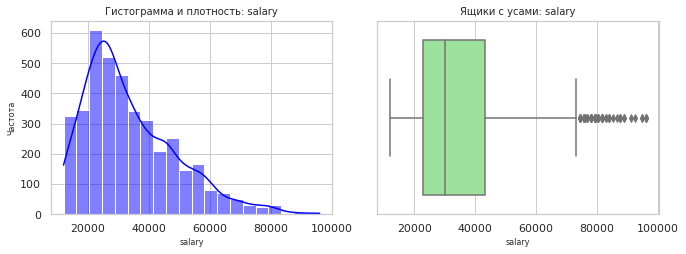

In [355]:
# Используем функцию, созданную для Задачи 1.
histogram_and_boxplot(quit_train, numeric_cols_train)

Изучив гистограммe и ящики с усами, мы видим, что:

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 20 - 25 тысяч.


**Гистограмма вида countplot для дискретных числовых признаков**

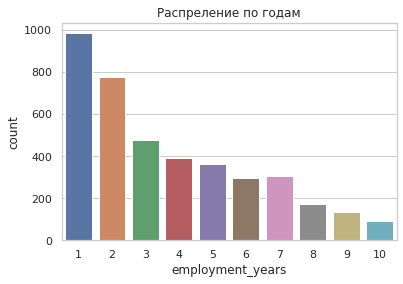

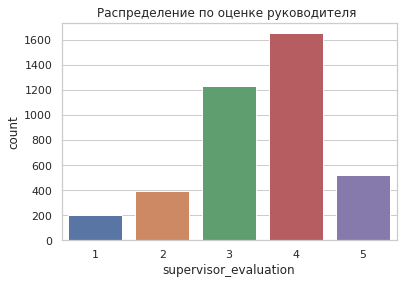

In [356]:
# Для признака employment_years
sns.countplot(data=quit_train, x='employment_years')
plt.title('Распреление по годам')
plt.show()

# Для признака supervisor_evaluation
sns.countplot(data=quit_train, x='supervisor_evaluation')
plt.title('Распределение по оценке руководителя ')
plt.show()

Изучив гистограммы вида countplot для дискретных числовых признаков, мы видим, что:

- в выборке преобладают сотрудники, которые проработали 1, 2 или 3 года, больше всего тех, кто проработл 1 год, меньше всего тех, кто проработал 10 лет;

- в выборке больше всего тех, кого оценивают на "3" и "4", самая многочисленная группа - те, кого оценка "3", самая малочисленная группа - те, у кого оценка "1"

In [357]:
# Определим категориальные и порядковые признаки
cat_ord_columns = ["dept", "level", "workload"]

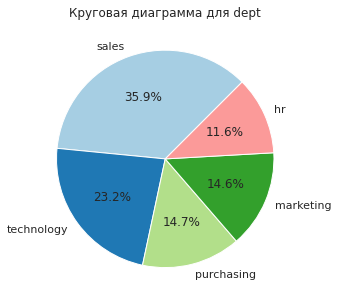

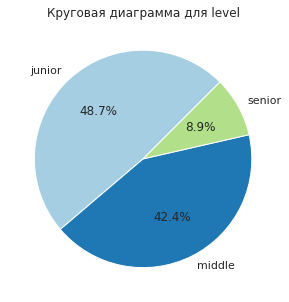

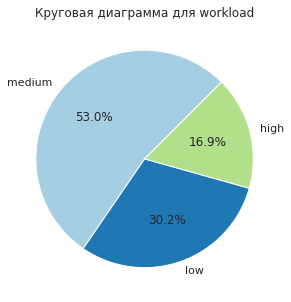

In [358]:
# Используем функцию, созданную для Задачи 1
draw_pie_diagram(quit_train, cat_ord_columns)

Изучив круговые диаграммы, мы можем сказать, что:

- больше всего сотрудников работает в отделах sales - 35.9% и в technology - 23.2%,

- в других отделах: purchasing - 14.7%, marketing - 14.6%, hr - 11.6%;

- значительное большинство сотрудников имеют грейд junior или middle - 48.7 % и 42.4%, лишь оставшиеся 8.9% - senior.

- уровень загруженности большинства сотрудников средний, их 53.0%, сотрудников с высоким уровнем загруженности 16.9 % и 30.2% с низким уровнем загруженности.

Посмотрим, как соотносятся поазатели числовых признаков для уволившихся и не уволившихся сотрудников,



Рассмотрим непрерывные числовые признаки 

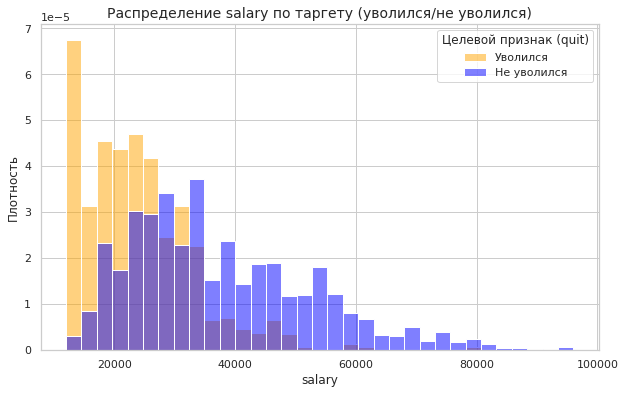

In [359]:
# Определяем числовые признаки
numeric_columns = ['salary']

# Задаем стили для графиков
sns.set(style="whitegrid")

# Определяем цвета для каждого класса
colors = {0: "blue", 1: "orange"}

# Функция для создания гистограммы с наложением по таргету
def plot_histograms(data, numeric_columns, target_column):
    for column in numeric_columns:
        plt.figure(figsize=(10, 6))

        # Гистограммы с нормализацией по плотности (density=True)
        sns.histplot(data, x=column, hue=target_column, stat="density", common_norm=False, palette=colors)

        plt.title(f'Распределение {column} по таргету (уволился/не уволился)', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Плотность', fontsize=12)

        # Настройка легенды и меток
        plt.legend(title="Целевой признак (quit)", labels=['Уволился', 'Не уволился'])

        plt.grid(True)
        plt.show()

# Построим гистограммы для этих признаков
plot_histograms(quit_train, numeric_columns, 'quit')


Рассмотрим дискретные числовые признаки 

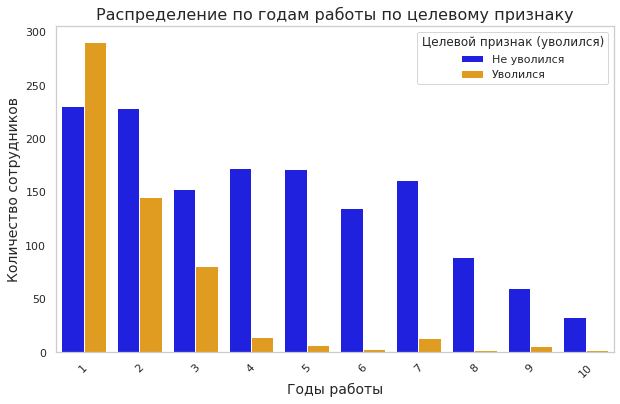

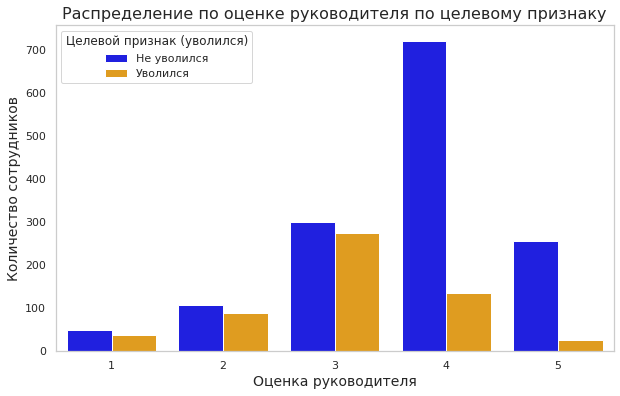

In [360]:
# Определяем цвета для каждого класса
colors = {0: "blue", 1: "orange"}

# График для признака employment_years с учетом целевого признака
plt.figure(figsize=(10, 6))
sns.countplot(data=quit_test, x='employment_years', hue='quit', palette=colors)  
plt.title('Распределение по годам работы по целевому признаку', fontsize=16)
plt.xlabel('Годы работы', fontsize=14)
plt.ylabel('Количество сотрудников', fontsize=14)
plt.xticks(rotation=45)  # Поворачиваем метки по оси X, если нужно
plt.legend(title="Целевой признак (уволился)", labels=['Не уволился', 'Уволился'])
plt.grid(axis='y')
plt.show()

# График для признака supervisor_evaluation с учетом целевого признака
plt.figure(figsize=(10, 6))
sns.countplot(data=quit_test, x='supervisor_evaluation', hue='quit', palette=colors)  
plt.title('Распределение по оценке руководителя по целевому признаку', fontsize=16)
plt.xlabel('Оценка руководителя', fontsize=14)
plt.ylabel('Количество сотрудников', fontsize=14)
plt.legend(title="Целевой признак (уволился)", labels=['Не уволился', 'Уволился'])
plt.grid(axis='y')
plt.show()


На графиках видно, что уволившиеся преобладают среди тех, кто работает год, а среди тех, то работает более 4 лет их совсем мало.

Отличники и хорошисты, то есть те, кого начальство оценивает отлично и хорошо, увольняются значительно реже, чем те, кто имеет оценки ниже.

Больше всего уволишихся среди тех, кто получает самую небольшую зарплату < 20 000, а среди тех, кто получает от 35 000 увольняющихся очень немного.

Построим матрицу корреляций

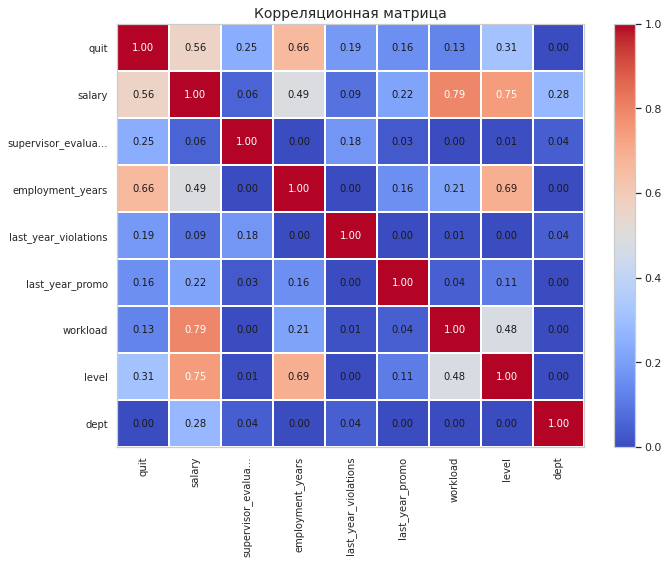

In [361]:
# Создаём список с непрерывных числовых признаков
interval_cols = [
    'supervisor_evaluation',
    'salary'
]

# Считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(quit_train.drop('id', axis=1), interval_cols=numeric_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'Корреляционная матрица',
    fontsize_factor=1,
    figsize=(10, 8),
)

Мы видим, что увольнение сотрудника коррелирует со следующими факторами:
- количество лет, проведенных в компании, чем меньше сотрудник работает, тем больше вероятность, что уйдет;
- зарплата, чем меньше зарплата, тем больше вероятность, что сотрудник уйдет (корреляция средней силы)

Матрица фик не отразила отрицательный характер корреляции, лишь ее силу, но мы видели его на других графиков.

Мы уже исследовали данные test-вой выборки в Задаче 1 и убедились, что они имеют очень похожие показатели.

**Портрет уволившегося пострудника**

Выделим в отдельный датасет данные уволившихся сотрудников и посмотрим,
- в каких отделах они работали,
- на какой должности (какой имели грейд),
- сколько лет работали в компании,
- какая была загруженность,
- получали ли повышение за год,
- имели ли нарушения за год,
- какую имели зарплату

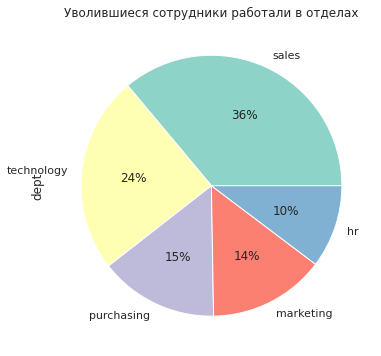

In [362]:
color_palette = sns.color_palette("Set3")
quit_train.loc[quit_train['quit'] == 1, 'dept'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Уволившиеся сотрудники работали в отделах', colors = color_palette, figsize = (14, 6))
plt.show()

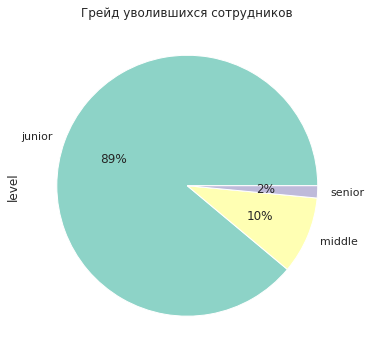

In [363]:
quit_train.loc[quit_train['quit'] == 1, 'level'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Грейд уволившихся сотрудников', colors = color_palette, figsize = (14, 6))
plt.show()

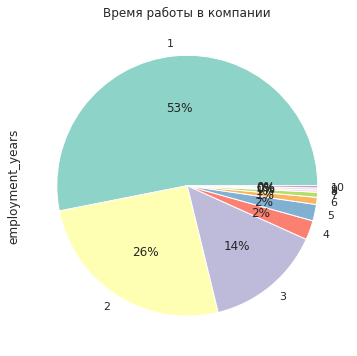

In [364]:
quit_train.loc[quit_train['quit'] == 1, 'employment_years'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Время работы в компании', colors = color_palette, figsize = (14, 6))
plt.show()

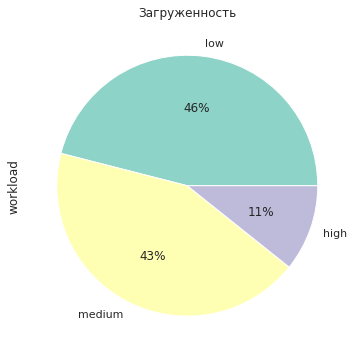

In [365]:
quit_train.loc[quit_train['quit'] == 1, 'workload'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Загруженность', colors = color_palette, figsize = (14, 6))
plt.show()

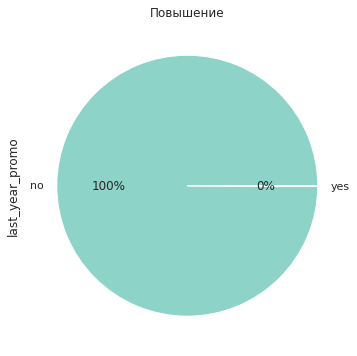

In [366]:
quit_train.loc[quit_train['quit'] == 1, 'last_year_promo'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Повышение', colors = color_palette, figsize = (14, 6))
plt.show()

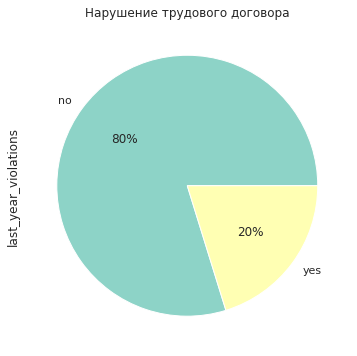

In [367]:
quit_train.loc[quit_train['quit'] == 1, 'last_year_violations'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Нарушение трудового договора', colors = color_palette, figsize = (14, 6))
plt.show()

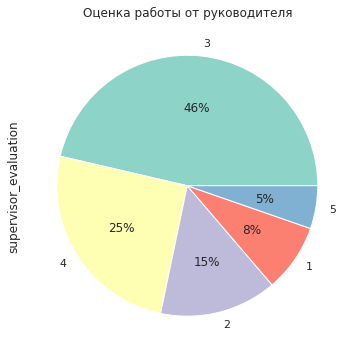

In [369]:
quit_train.loc[quit_train['quit'] == 1, 'supervisor_evaluation'].value_counts().plot(y = 'count', kind = 'pie', autopct='%1.0f%%', title = 'Оценка работы от руководителя', colors = color_palette, figsize = (14, 6))
plt.show()

Грейд уволившихся сотрудников значительно отличается от общего распределения: 89% уволившихся junior, 10 % middle, хотя в общем распределении соотношение junior и middle 48.7 и 42.4 %.

В абсолютном большинстве те, кто не получал повышение, почти 100%.

Подавляющее большинство уволившихся работает в компании 1 - 3 года.

Почти половина уволившихся получила оценку 3 от руководителя.

Загруженность уволившихся сотрудников не отличается от загруженности всех сотрудников выборки.

In [377]:
def format_float(x):
    return f"{x:.2f}"

# Вычисляем статистику по группам (уволившиеся и оставшиеся)
stats = quit_train.groupby('quit')[['salary', 'employment_years']].agg(['mean', 'median'])
stats.index = ['Оставшиеся', 'Уволившиеся']

# Переформатируем DataFrame для лучшей читаемости
stats = stats.applymap(format_float)
stats.columns = pd.MultiIndex.from_tuples([
    ('Зарплата', 'Среднее'),
    ('Зарплата', 'Медиана'),
    ('Годы работы', 'Среднее'),
    ('Годы работы', 'Медиана')
])

print("Статистика по сотрудникам:")
display(stats)

# Вычисляем и выводим разницу в процентах
diff_percent = ((stats.loc['Уволившиеся'].astype(float) / stats.loc['Оставшиеся'].astype(float) - 1) * 100)
diff_percent = diff_percent.apply(format_float)
print("\nРазница в процентах (уволившиеся по отношению к оставшимся):")
display(diff_percent)

# Дополнительно выводим общее количество сотрудников в каждой группе
total_counts = quit_train['quit'].value_counts().sort_index()
total_counts.index = ['Оставшиеся', 'Уволившиеся']
print("\nКоличество сотрудников в каждой группе:")
display(total_counts)
print(f"Процент уволившихся: {(total_counts['Уволившиеся'] / total_counts.sum() * 100):.2f}%")

Статистика по сотрудникам:


Зарплата           Годы работы        
              Среднее   Медиана     Среднее Медиана
Оставшиеся   37702.23  34800.00        4.43    4.00
Уволившиеся  23885.11  22800.00        1.84    1.00


Разница в процентах (уволившиеся по отношению к оставшимся):


Зарплата     Среднее    -36.65
             Медиана    -34.48
Годы работы  Среднее    -58.47
             Медиана    -75.00
dtype: object


Количество сотрудников в каждой группе:


Оставшиеся     2872
Уволившиеся    1128
Name: quit, dtype: int64

Процент уволившихся: 28.20%


**Исследуем взаимосвязь уровня удовлетворенности сотрудника работой и его увольнения**
Для этого используем тестовую выборку.

In [378]:
jsr_y_test.head()

0    0.79
1    0.72
2    0.64
3    0.60
4    0.75
Name: job_satisfaction_rate, dtype: float64

In [382]:
try:
    jsr_y_test = pd.read_csv("/datasets/test_target_job_satisfaction_rate.csv")
except:
    jsr_y_test = pd.read_csv("datasets/test_target_job_satisfaction_rate.csv")

# Для тестовой выборки нам известен и уровень удовлетворенности, и quit
test_with_jsr = quit_test.merge(jsr_y_test, on = "id", how = "inner")
test_with_jsr.shape

(2000, 11)

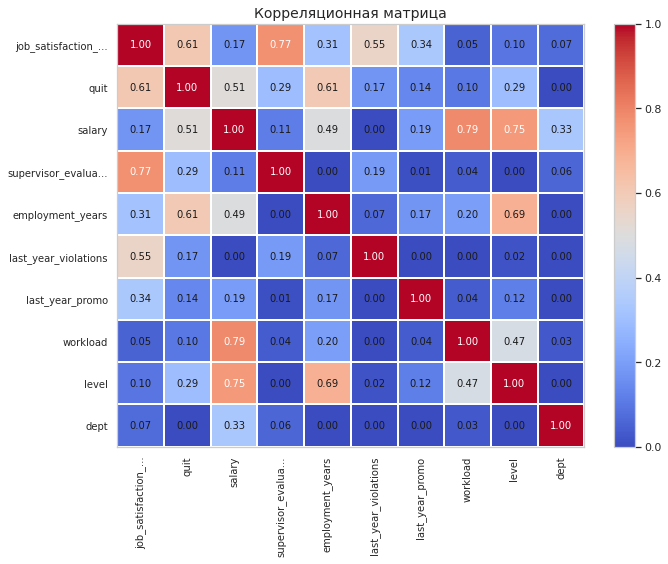

In [383]:
# Создаём список с наименованиями непрерывных числовых признаков
numeric_cols = [
    'salary',
    'job_satisfaction_rate'
]

# Считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(test_with_jsr.drop(["id"], axis = 1), interval_cols=numeric_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'Корреляционная матрица',
    fontsize_factor=1,
    figsize=(10, 8),
)

Мы видим выраженную корреляцию между job_satisfaction_rate и quit.

Изучим, как сооотносится кривая распределения уровня удовлетворенности работой среди уволившихся и не уволившихся сотрудников.

In [384]:
test_with_jsr_resigned = test_with_jsr.query('quit == 1')['job_satisfaction_rate']
test_with_jsr_not_resigned = test_with_jsr.query('quit == 0')['job_satisfaction_rate']

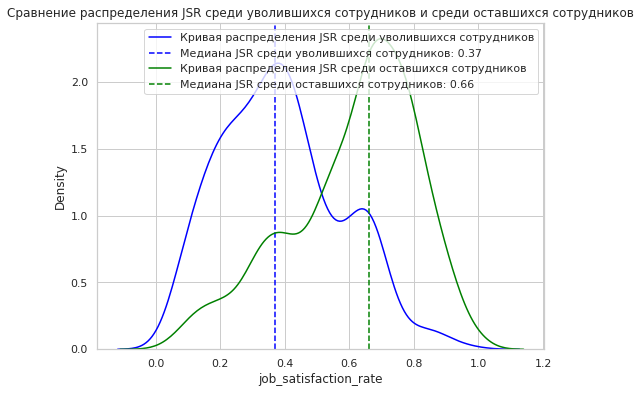

In [385]:
# Создание фигуры и осей
fig, axes = plt.subplots(figsize=(8, 6))

# Распределение показателя удовлетворенностью работой среди уволившихся сотрудников
sns.kdeplot(data=test_with_jsr_resigned, label='Кривая распределения JSR среди уволившихся сотрудников', ax=axes, color='blue')

# Медиана для распределения показателя удовлетворенностью работой среди уволившихся сотрудников
mean_resigned = test_with_jsr_resigned.median()
axes.axvline(mean_resigned, color='blue', linestyle='--', label=f'Медиана JSR среди уволившихся сотрудников: {mean_resigned:.2f}')

# Распределение показателя удовлетворенностью работой среди оставшихся сотрудников
sns.kdeplot(data=test_with_jsr_not_resigned, label='Кривая распределения JSR среди оставшихся сотрудников', ax=axes, color='green')

# Медиана для распределения показателя удовлетворенностью работой среди оставшихся сотрудников
mean_not_resigned = test_with_jsr_not_resigned.median()
axes.axvline(mean_not_resigned, color='green', linestyle='--', label=f'Медиана JSR среди оставшихся сотрудников: {mean_not_resigned:.2f}')

# Настройки заголовка и легенды
axes.set_title('Сравнение распределения JSR среди уволившихся сотрудников и среди оставшихся сотрудников')
plt.legend(loc='best')

# Показ графика
plt.show()

Медианы распределения уровня удовлетворенности работой уволившихся и не уволивщихся значительно различаются, они составляют 37% и 66%, взаимосвязь уровня удовлетворенности работой и увольнения присутствует в достаточной степени, чтоб сделать уровень удовлетворенности работой новым признаком для предсказания увольнения.

**Выводы**

I. Мы провели исследовательский анализ данных и обнаружили:

1)

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 20 - 25 тысяч.

2)

- в выборке преобладают сотрудники, которые проработали 1, 2 или 3 года, больше всего тех, кто проработл 1 год, меньше всего тех, кто проработал 10 лет;

- в выборке больше всего тех, кого оценивают на "3" и "4", самая многочисленная группа - те, кого оценка "3", самая малочисленная группа - те, у кого оценка "1"


3)

- уволившиеся преобладают среди тех, кто работает год, а среди тех, то работает более 4 лет их совсем мало.

- отличники и хорошисты, то есть те, кого начальство оценивает отлично и хорошо, увольняются значительно реже, чем те, кто имеет оценки ниже.

- больше всего уволишихся среди тех, кто получает самую небольшую зарплату < 20 000, а среди тех, кто получает от 35 000 увольняющихся очень немного.

4)

- больше всего сотрудников работает в отделах sales - 35.9% и в technology - 23.2%,
- в других отделах: purchasing - 14.7%, marketing - 14.6%, hr - 11.6%;
- значительное большинство сотрудников имеют грейд junior или middle - 48.7 % и 42.4%, лишь оставшиеся 8.9% - senior.
- уровень загруженности большинства сотрудников средний, их 53.0%, сотрудников с высоким уровнем загруженности 16.9 % и 30.2% с низким уровнем загруженности.

5)

Мы видим, что увольнение сотрудника коррелирует со следующими факторами:
- количество лет, проведенных в компании, чем меньше сотрудник работает, тем больше вероятность, что уйдет;
- зарплата, чем меньше зарплата, тем больше вероятность, что сотрудник уйдет (корреляция средней силы)


II. Мы составили портрет уволившегося сотрудника:

- Грейд уволившихся сотрудников значительно отличается от общего распределения: 89% уволившихся junior, 10 % middle, хотя в общем распределении соотношение junior и middle 48.7 и 42.4 %.
- В абсолютном большинстве те, кто не получал повышение, почти 100%.
- Подавляющее большинство уволившихся работает в компании 1 - 3 года.
- Почти половина уволившихся получила оценку 3 от руководителя.
- По уровню загруженности уволившиеся затрудники не имеют значительных отличий.
- Средняя зарплата уволившегося сотрудника 23885, тогда как средняя зарплата по все выборке 33805.8


III. Мы увидели достаточно выраженную корреляцию между уровнем удовлетворенности работой и возможностью увольнения: чем меньше уровень удовлетворенности, тем вероятнее увольнение.


**Шаг 4. Добавление нового признака**

На данном шаге наша задача - добавить новый признак в quit_train и quit_test

Чтобы получить новый признак - уровень удовлетворенности работой, - мы
- выделяем признаки 
- заполняем неявные пропуски и затем используем preprocessor из Задачи 1,
- предсказываем моделью из Задачи 1 уровень удовлетворенности сотрудников


In [386]:
quit_X_train = quit_train.drop(["quit"], axis = 1)

quit_X_train = replace_spaces(quit_X_train)
quit_X_train = preprocessor.transform(quit_X_train)

# Получаем предсказания
new_feature_train = jsr_best_model.predict(quit_X_train)

In [387]:
quit_X_test = quit_test.drop(["quit"], axis = 1)

quit_X_test = replace_spaces(quit_X_test)
quit_X_test = preprocessor.transform(quit_X_test)

# Получаем предсказания
new_feature_test = jsr_best_model.predict(quit_X_test)

Выводы: использовав обработку данных и лучшую модель из Задачи 1, мы предсказали уровень удовлетворенности работой для выборок quit_test и quit_train Задачи 2 и получили новый признак.

**Шаг 5. Подготовка данных**

На данном шаге:

- Избавимся от индексов-идентификаторов сотрудников, чтобы не путать модели.

- Разделим выборки quit_train на quit_X_train и quit_y_train, добавим к quit_X_train новый признак, quit_test на quit_X_test и quit_y_test.

- При этом мы определим датасеты заново, так как они были обработан preprocessor из первой задачи, а нам нужно использовать новый пайплайн для обработки данных.

- Создадим новый pipeline и обработаем признаки, он аналогичен pipeline preprocessor из Задачи 1, но в числовые признаки добавлен новый признак уровень удовлетворенности работой. Pipeline подготовки данных будет включать:

    - заполнени пропусков: мы его уже сделали, но, тем не менее, добавим заполнение пропусков в общий pipeline

    - масштабирование Standard Scaler для числовых признаков

    - кодирование Ordinal Encoder для порядковых признаков

    - кодирование One Hot Encoder для категориальных признаков

In [388]:
quit_X_train = quit_train.drop(["id", "quit"], axis = 1)
quit_X_train["job_satisfaction_rate"] = new_feature_train
quit_y_train = quit_train["quit"]

In [389]:
quit_X_test = quit_test.drop(["id", "quit"], axis = 1)
quit_X_test["job_satisfaction_rate"] = new_feature_test
quit_y_test = quit_test["quit"]

In [390]:
# Определим числовые, порядковые и категориальные признаки
numeric_cols = ["employment_years", "supervisor_evaluation", "job_satisfaction_rate", "salary"]
ordinal_cols = ["dept", "last_year_promo", "last_year_violations"]
categorical_cols = ["level", "workload"]

In [391]:
quit_X_train = replace_spaces(quit_X_train)
quit_X_test = replace_spaces(quit_X_test)
quit_X_train = preprocessor.fit_transform(quit_X_train)
quit_X_test = preprocessor.transform(quit_X_test)

**Вывод**: Мы использовали pipeline из Задачи 1, лишь несколько видоизменив его: добавлен новый чиловой признак уровень удовлетворенностью работой, обработали данные тренировочной и тестовой выборки.

**Шаг 6. Обучение моделей**

Используем следующие алгоритмы для предсказания увольнения сотрудников, т.е. для классификации на тех, кто уволится, и тех, кто не уволится:

- Логистическая регрессия LogisticRegression

- Деревой решений DesicionTreeClassifier

- Случайный лес RandomForestClassifier

- Градиентный бустинг на деревьях решений CatBoost

В качестве метрики оценки будем использовать ROC-AUC, желательный показатель метрики больше или равен 0.91

После первоначального тестирования алгоритмов выберем два наиболее подходящих и найдем для них лучшие гиперпараметры инструментами поиска по сетке GridSearch и случайного поиска RandomizedSearch.

In [392]:
# Создаем Pipeline и добавляем модели в сетку гиперпараметров
pipeline = Pipeline([
    ('model', LogisticRegression())  
])

# Сетка гиперпараметров для всех моделей
param_grid = [
    # Параметры для LogisticRegression (нет гиперпараметров)
    {
        'model': [LogisticRegression()],
    },
    # Параметры для DecisionTreeClassifier
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth': range(1, 21)
    },
    # Параметры для RandomForestClassifier
    {
        'model': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': range(5, 16, 2)
    },
    # Параметры для CatBoostClassifier
    {
        'model': [CatBoostClassifier(random_state=RANDOM_STATE, silent=True)],
        'model__iterations': [100, 130, 150],
        'model__depth': [6, 7, 8]
    }
]

# Настройка GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc_ovr",
    cv=3,
    verbose=1
)

# Обучение модели на тренировочной выборке
grid_search.fit(quit_X_train, quit_y_train)

# Выводим лучшие параметры и модель
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Лучшая модель: {best_params['model'].__class__.__name__}")
print(f"Лучшие параметры: {best_params}")
print(f"Лучший результат roc_auc на кросс-валидации: {best_score}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Лучшая модель: CatBoostClassifier
Лучшие параметры: {'model': <catboost.core.CatBoostClassifier object at 0x7f291c1bd1c0>, 'model__depth': 6, 'model__iterations': 100}
Лучший результат roc_auc на кросс-валидации: 0.9411068347398429


Выбираем алгоритм CatBoostClassifier для предсказания

In [393]:
# Оценка лучшей модели на тестовой выборке
best_model = grid_search.best_estimator_
quit_y_pred_proba = best_model.predict_proba(quit_X_test)[:, 1]

# Вычисляем SMAPE на тестовой выборке
roc_auc_test = roc_auc_score(quit_y_test, quit_y_pred_proba)
print(f"roc_auc на тестовой выборке: {roc_auc_test}")

roc_auc на тестовой выборке: 0.9338940170686896


**Вывод**:

Мы рассмотрели следующие алгоритмы для задачи классификации - предсказания увольнения сотрудника:
- Логистическая регрессия LogisticRegression
- Деревой решений DesicionTreeClassifier
- Случайный лес RandomForestClassifier
- Градиентный бустинг на деревьях решений CatBoostClassifier

Мы использовали ROC-AUC для оценки, и желательным показателем метрики был больше или равно 0.91, мы получили очень хороший показатель 0.93 при помощи алгоритма CatBoostClassifier и предсказали увольнение сотрудников.

**Шаг 7. Выводы**

Задача 2 состояла в том, чтобы предсказать увольнение сотрудника.
Мы получили три датасета: quit_train, признаки выборки quit_test, целевой показатель выборки quit_test - "quit", при этом признаки quit_test те же, что и в первой задаче.

Мы загрузили и исследовали датасеты, в них не было неподходящих типов данных и дублей, но в quit_test были явные и неявные пропуски, которые мы заполнили при помощи пайплайна SimpleImputer из Задачи 1.

Мы провели исследовательский анализ данных и обнаружили:

1)

- половина сотрудников получает зарплату в интервале 22 - 43 тысячи, медианное значение составляет около 30 тысяч, а самое частотное 20 - 25 тысяч.

2)

- в выборке преобладают сотрудники, которые проработали 1, 2 или 3 года, больше всего тех, кто проработл 1 год, меньше всего тех, кто проработал 10 лет;

- в выборке больше всего тех, кого оценивают на "3" и "4", самая многочисленная группа - те, кого оценка "3", самая малочисленная группа - те, у кого оценка "1"


3)

- уволившиеся преобладают среди тех, кто работает год, а среди тех, то работает более 4 лет их совсем мало.

- отличники и хорошисты, то есть те, кого начальство оценивает отлично и хорошо, увольняются значительно реже, чем те, кто имеет оценки ниже.

- больше всего уволишихся среди тех, кто получает самую небольшую зарплату < 20 000, а среди тех, кто получает от 35 000 увольняющихся очень немного.

4)

- больше всего сотрудников работает в отделах sales - 35.9% и в technology - 23.2%,
- в других отделах: purchasing - 14.7%, marketing - 14.6%, hr - 11.6%;
- значительное большинство сотрудников имеют грейд junior или middle - 48.7 % и 42.4%, лишь оставшиеся 8.9% - senior.
- уровень загруженности большинства сотрудников средний, их 53.0%, сотрудников с высоким уровнем загруженности 16.9 % и 30.2% с низким уровнем загруженности.

5)

Мы видим, что увольнение сотрудника коррелирует со следующими факторами:
- количество лет, проведенных в компании, чем меньше сотрудник работает, тем больше вероятность, что уйдет;
- зарплата, чем меньше зарплата, тем больше вероятность, что сотрудник уйдет (корреляция средней силы)

Мы составили портрет уволившегося сотрудника:

- Грейд уволившихся сотрудников значительно отличается от общего распределения: 89% уволившихся junior, 10 % middle, хотя в общем распределении соотношение junior и middle 48.7 и 42.4 %.
- В абсолютном большинстве те, кто не получал повышение, почти 100%.
- Подавляющее большинство уволившихся работает в компании 1 - 3 года.
- Почти половина уволившихся получила оценку 3 от руководителя.
- По уровню загруженности уволившиеся затрудники не имеют значительных отличий.
- Средняя зарплата уволившегося сотрудника 23885, тогда как средняя зарплата по все выборке 33805.8


Мы увидели достаточно выраженную корреляцию между уровнем удовлетворенности работой и возможностью увольнения: чем меньше уровень удовлетворенности, тем вероятнее увольнение.

Использовав лучшую модель из Задачи 1, мы предсказали уровень удовлетворенности работой для выборки quit_train и quit_test Задачи 2 и получили новый признак.

Затем мы обработали признаки при помощи pipeline из Задачи 1, лишь несколько видоизменив его: добавили новый числовой признак - уровень удовлетворенностью работой.

Затем мы подобрали лучшую модель для предсказания увольнения сотрудников, то есть для решения задачи бинарной классификации.

Мы рассмотрели следующие алгоритмы:
- Логистическая регрессия LogisticRegression
- Деревой решений DesicionTreeClassifier
- Случайный лес RandomForestClassifier
- Градиентный бустинг на деревьях решений CatBoostClassifier

Мы использовали ROC-AUC для оценки, и желательным показателем метрики был больше или равно 0.91, мы получили очень хороший показатель 0.93 при помощи алгоритма CatBoostClassifier и предсказали увольнение сотрудников.

Мы можем сделать вывод, что большая часть увольняющихся сотрудников, это junior-ы, которые работают 1-3 года, действительно, на начальном этапе развития карьеры может быть частая смена работодателя.

В то же время, мы видим, что уволившиеся - это в основном те, кто не получил повышение за год, кто не был в числе хорошистов и отличников с точки зрения начальства, можно сказать, что это сотрудники, которые почувствовали себя недооцененными, и, может быть, действительно были недооценены или же оказались не в самых благоприятных обстоятельствах, могут быть разные объяснения, вероятно, молодых сотрудников следует каким-то образом поддерживать, повышать, выражать благодарность или повышать зарплату.

# Общий вывод по проекту:

Описание задач:

В рамках проекта были поставлены две задачи:

    Предсказание уровня удовлетворенности сотрудников на основе их характеристик: грейд, отдел, оценка руководителя, количество лет на текущей работе, зарплата, загруженность, наличие повышения за последний год, нарушение договора за год.
    Предсказание увольнения сотрудников, основываясь на тех же признаках, а также на уровне удовлетворенности сотрудников, который был предсказан в первой задаче.

Этапы работы:

    Предобработка данных:
        Проведена очистка данных: дубликаты не были найдены, но были выявлены явные и неявные пропуски, которые заполнили с помощью пайплайна SimpleImputer.
        Выполнено масштабирование числовых признаков с использованием StandardScaler и кодирование категориальных признаков с применением OneHotEncoder и OrdinalEncoder.

    Исследовательский анализ данных (EDA):
        Был проведен глубокий анализ распределений по каждому признаку.
        Выявлены важные зависимости: удовлетворенность работой положительно коррелировала с оценкой руководителя и повышением, а увольнение отрицательно коррелировало с уровнем зарплаты, грейдом и оценками руководителя.

    Моделирование:
        Для первой задачи протестированы модели линейной регрессии, Decision Tree Regressor, Random Forest Regressor и CatBoostRegressor. Лучшая модель — CatBoostRegressor — показала SMAPE 10.88, что соответствует высокому качеству прогноза.
        Для второй задачи были рассмотрены классификационные модели: Logistic Regression, DecisionTreeClassifier, RandomForestClassifier и CatBoostClassifier. Лучшая модель — CatBoostClassifier — дала результат ROC-AUC = 0.93, что превышает целевой показатель 0.91.

    Подбор гиперпараметров:
        В обоих задачах использовались методы поиска по сетке (GridSearch), что позволило улучшить результаты.

Выводы:

    Задача 1: Удовлетворенность сотрудников:
        Большая часть сотрудников работает в компании от 1 до 3 лет, наибольшая группа — это сотрудники с грейдом junior, которые получают оценки 3-4 от руководителей и зарплату около 25-30 тысяч рублей.
        Уровень удовлетворенности в значительной степени зависит от наличия повышения за год и отсутствия нарушений договора.
        Выбранная модель CatBoostRegressor продемонстрировала высокое качество предсказаний удовлетворенности сотрудников, что может быть использовано для внутреннего мониторинга и повышения эффективности управления персоналом.

    Задача 2: Увольнение сотрудников:
        Основные группы увольняющихся — это сотрудники с грейдом junior, которые проработали 1-3 года, с низкими зарплатами и оценками.
        Важно отметить, что увольнение чаще происходит среди тех, кто не получает повышения и имеет низкие оценки от руководителей, что может свидетельствовать о чувстве недооцененности.

Рекомендации для бизнеса:

    Повышение уровня удовлетворенности сотрудников: Рекомендуется развивать программы повышения квалификации для сотрудников junior, предоставляя им больше возможностей для карьерного роста и повышения зарплат. Также стоит усилить признание и поощрение успешных сотрудников, чтобы снизить вероятность их ухода.

    Предотвращение увольнений: Бизнесу следует обратить внимание на сотрудников, которые работают от 1 до 3 лет, особенно на тех, кто не получил повышение. Программы мотивации и персонального развития могут уменьшить уровень увольнений в этой группе.

    Использование моделей для мониторинга: Внедрение модели для прогнозирования уровня удовлетворенности сотрудников поможет HR отделам вовремя выявлять сотрудников с низким уровнем удовлетворенности и предпринимать меры по улучшению их положения.